# Baseline Classification Models

**Objective:** Train and evaluate multiple classification models to predict job posting experience level using the feature-engineered dataset.

**Models to compare:**
- Logistic Regression (baseline)
- XGBoost
- LightGBM
- CatBoost

**Target variable:** `experience_level_ord` (ordinal-encoded experience level)

All training and evaluation logic is implemented in `src/` and called from this notebook.

## 1. Setup and Data Loading

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Make src/ importable
sys.path.append("..\src")

print("Setup complete.")

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ognjen.vujovic\AppData\Local\Temp\ipykernel_1344\1577299763.py:12: SyntaxWarning: invalid escape sequence '\s'
  sys.path.append("..\src")


Setup complete.


In [2]:
TRAIN_PATH = "../data/processed/feature_matrix_train.csv"
TEST_PATH = "../data/processed/feature_matrix_test.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

Train shape: (98589, 44)
Test shape:  (24709, 44)


## 2. Target and Feature Split

### 2.1 Define target and feature columns

The target is `experience_level_ord`, which is the ordinal encoding of experience level. Since this column *is* the target, it must be excluded from the feature set.

Rows where the target is missing are dropped since they cannot be used for supervised training.

In [3]:
TARGET = "experience_level_ord"

# Drop rows where target is missing
train_before = len(df_train)
test_before = len(df_test)

df_train = df_train.dropna(subset=[TARGET]).reset_index(drop=True)
df_test = df_test.dropna(subset=[TARGET]).reset_index(drop=True)

FEATURES = [col for col in df_train.columns if col != TARGET]

X_train = df_train[FEATURES]
y_train = df_train[TARGET].astype(int)

X_test = df_test[FEATURES]
y_test = df_test[TARGET].astype(int)


print(f"Train: {train_before} -> {len(df_train)} ({train_before - len(df_train)} dropped due to missing target)")
print(f"Test:  {test_before} -> {len(df_test)} ({test_before - len(df_test)} dropped due to missing target)")

Train: 98589 -> 79440 (19149 dropped due to missing target)
Test:  24709 -> 19948 (4761 dropped due to missing target)


### 2.2 Class distribution

Check if the target classes are balanced or if we need to account for imbalance during training.

In [4]:
class_dist = y_train.value_counts().sort_index()
class_pct = y_train.value_counts(normalize=True).sort_index() * 100

dist_df = pd.DataFrame({
    "count": class_dist,
    "percentage": class_pct.round(2)
})
dist_df.index.name = "experience_level"
print(dist_df)
print(f"\nNumber of classes: {y_train.nunique()}")

                  count  percentage
experience_level                   
0                  1594        2.01
1                 29457       37.08
2                  8504       10.70
3                 34824       43.84
4                  3733        4.70
5                  1328        1.67

Number of classes: 6


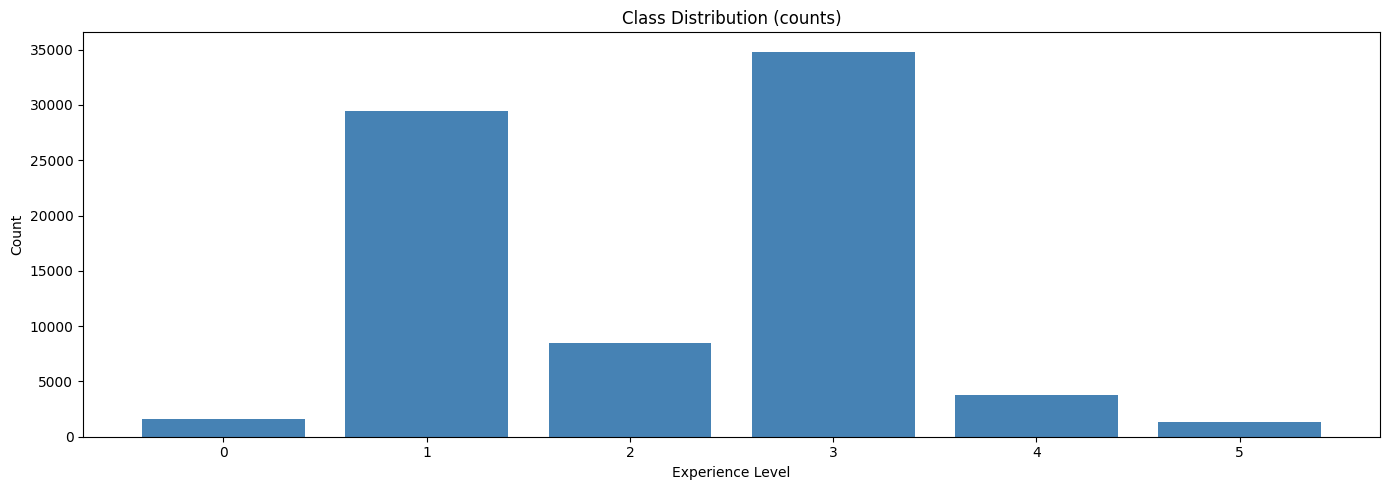

In [5]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Absolute counts
axes.bar(class_dist.index.astype(str), class_dist.values, color="steelblue")
axes.set_title("Class Distribution (counts)")
axes.set_xlabel("Experience Level")
axes.set_ylabel("Count")

plt.tight_layout()
plt.show()

### 2.3 Missing values in features

Quick overview of which features have missing values and how much. This matters because Logistic Regression cannot handle NaNs natively, while tree-based models (XGBoost, LightGBM, CatBoost) can.

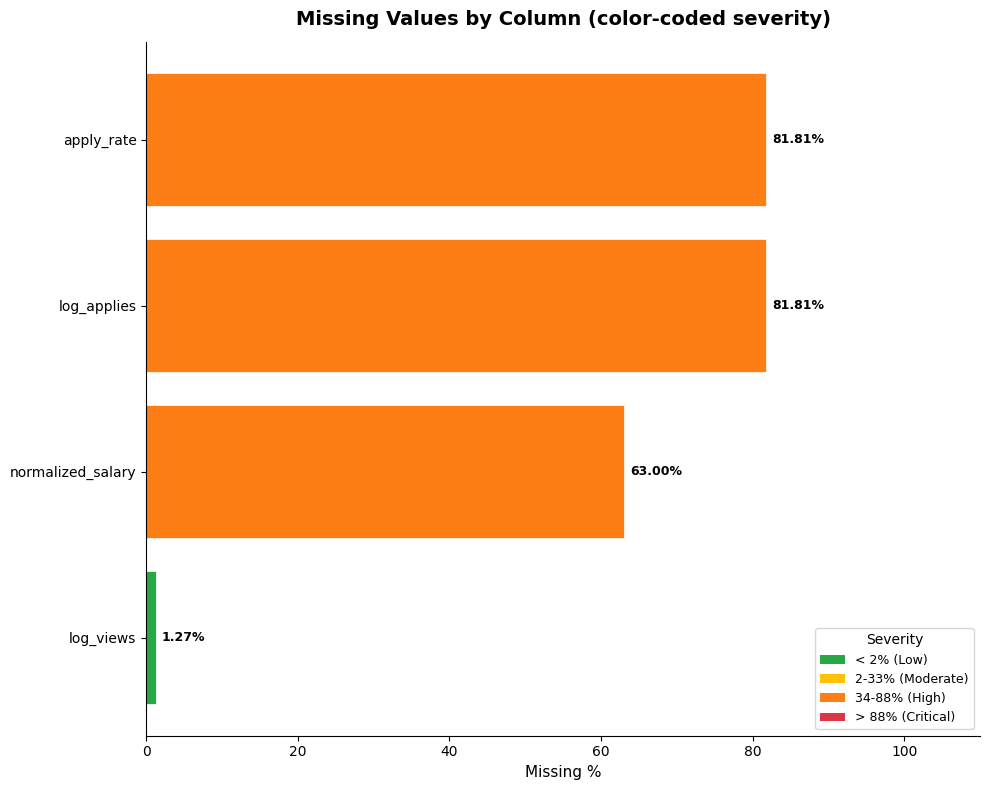

In [6]:
missing_pct = (df_train.isna().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]  # only columns with missing values

def severity_color(pct):
    if pct < 2:
        return '#28a745'   # green
    elif pct < 33:
        return '#ffc107'   # yellow
    elif pct < 88:
        return '#fd7e14'   # orange
    else:
        return '#dc3545'   # red

colors = [severity_color(p) for p in missing_pct.values]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')

legend_items = [
    Patch(facecolor='#28a745', label='< 2% (Low)'),
    Patch(facecolor='#ffc107', label='2-33% (Moderate)'),
    Patch(facecolor='#fd7e14', label='34-88% (High)'),
    Patch(facecolor='#dc3545', label='> 88% (Critical)')
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9, title='Severity', title_fontsize=10)

ax.set_xlabel('Missing %', fontsize=11)
ax.set_title('Missing Values by Column (color-coded severity)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0, 110)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Evaluation Utilities

Evaluation logic lives in `src/utils/evaluation.py` and is imported here. All models will be evaluated through the same functions for consistency.

**Key metric choices given class imbalance:**

| Class | Label | Share |
|-------|-------|-------|
| 0 | Internship | 2.01% |
| 1 | Entry level | 37.08% |
| 2 | Associate | 10.70% |
| 3 | Mid-Senior level | 43.84% |
| 4 | Director | 4.70% |
| 5 | Executive | 1.67% |

Classes 0, 4, and 5 together make up only ~8% of the data. A model predicting only class 1 and 3 would already reach ~81% accuracy, so accuracy alone is misleading. We track:

- **F1 macro** - primary metric, treats all 6 classes equally regardless of size
- **F1 weighted** - accounts for class frequency, gives a "realistic" performance view
- **Per-class precision/recall** - to see exactly where the model struggles (expect low recall on minority classes)
- **Normalized confusion matrix** - row-normalized so that minority classes are visible

In [7]:
from utils.evaluation import (
    evaluate_model,
    compare_models,
    plot_model_comparison,
    EXPERIENCE_LABELS,
)

print("Available experience level classes:")
for k, v in EXPERIENCE_LABELS.items():
    print(f"  {k} -> {v}")

Available experience level classes:
  0 -> Internship
  1 -> Entry level
  2 -> Associate
  3 -> Mid-Senior level
  4 -> Director
  5 -> Executive


### Evaluation workflow

Every model in the following sections will be evaluated with the same call:

```python
results["Model Name"] = evaluate_model(y_test, y_pred, model_name="Model Name")
```

This prints the classification report, shows the normalized confusion matrix, and stores the metrics dict for the final comparison. We initialize the results container here.

In [8]:
# Container to collect metrics from all models for final comparison
results = {}

## 4. Logistic Regression (Baseline)

Logistic Regression serves as the simplest baseline. It gives us a floor to beat with tree-based models.

**Why it needs extra preprocessing compared to tree models:**
- Cannot handle NaN natively, so median imputation is applied (~81% missing in apply-related features, ~63% in salary)
- Requires feature scaling since L2 regularization penalizes coefficients, and unscaled features with larger magnitudes would dominate

Both steps are wrapped inside a sklearn Pipeline so transforms stay consistent between train and test.

`class_weight='balanced'` is used to counteract the heavy class imbalance by weighting samples inversely proportional to class frequency.

In [9]:
from models.train_logreg import build_logreg_pipeline, get_feature_importance

### 4.1 Train

In [10]:
lr_pipeline = build_logreg_pipeline(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

### 4.2 Evaluate

  Logistic Regression

Accuracy:        0.3965
MAE:             1.0573
F1 (macro):      0.2962
F1 (weighted):   0.4132

                  precision    recall  f1-score   support

      Internship       0.12      0.53      0.20       376
     Entry level       0.58      0.59      0.58      7418
       Associate       0.30      0.43      0.35      2154
Mid-Senior level       0.66      0.22      0.33      8735
        Director       0.12      0.38      0.19       913
       Executive       0.07      0.41      0.12       352

        accuracy                           0.40     19948
       macro avg       0.31      0.43      0.30     19948
    weighted avg       0.55      0.40      0.41     19948



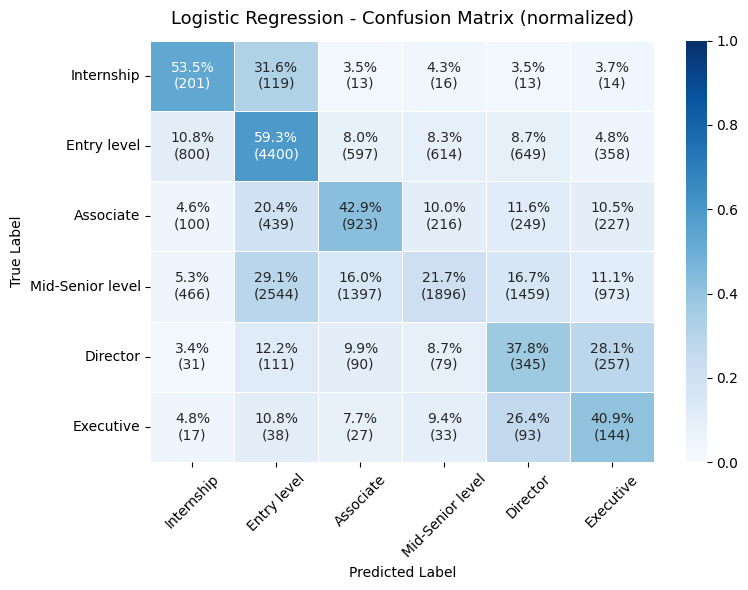

In [11]:
results["Logistic Regression"] = evaluate_model(
    y_test, y_pred_lr, model_name="Logistic Regression"
)

### 4.3 Feature importance

Mean absolute coefficient across all 6 classes. Larger values mean the feature has more influence on the decision boundaries. Since features are scaled, coefficients are directly comparable.

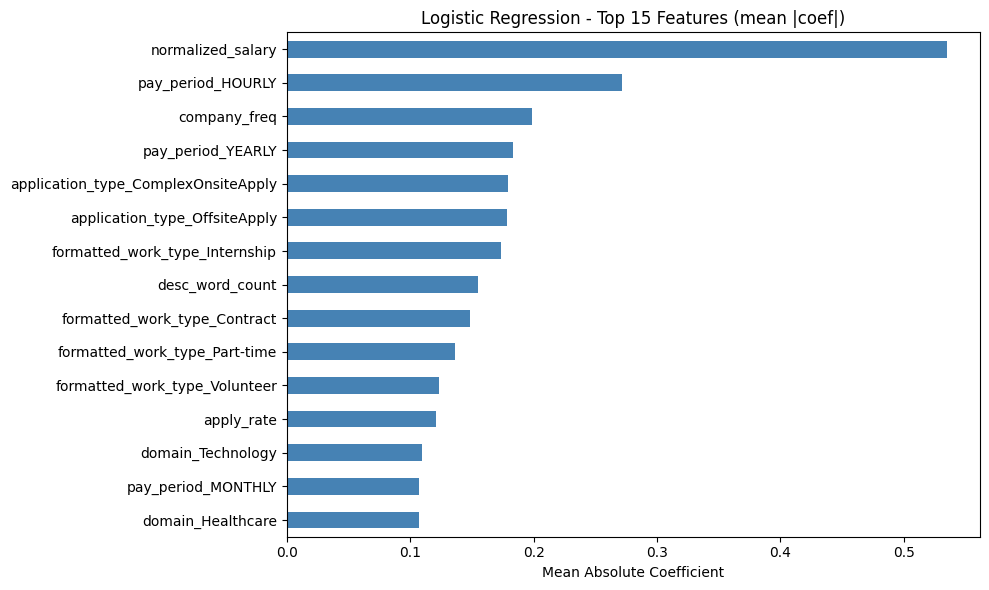

In [12]:
lr_importance = get_feature_importance(lr_pipeline, FEATURES, top_n=15)

fig, ax = plt.subplots(figsize=(10, 6))
lr_importance.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Logistic Regression - Top 15 Features (mean |coef|)")
ax.set_xlabel("Mean Absolute Coefficient")
plt.tight_layout()
plt.show()

In [13]:
print(results["Logistic Regression"])

{'accuracy': 0.3964808502105474, 'mae': 1.0572989773410868, 'f1_macro': 0.2962220857482449, 'f1_weighted': 0.4132475653403462, 'precision_macro': 0.31044110786327356, 'recall_macro': 0.426709204532646, 'precision_weighted': 0.5467258147885707, 'recall_weighted': 0.3964808502105474, 'classification_report': {'Internship': {'precision': 0.12445820433436533, 'recall': 0.5345744680851063, 'f1-score': 0.20190858864892014, 'support': 376.0}, 'Entry level': {'precision': 0.5750882237615997, 'recall': 0.5931517929361014, 'f1-score': 0.5839803570243547, 'support': 7418.0}, 'Associate': {'precision': 0.30292090580899245, 'recall': 0.4285051067780873, 'f1-score': 0.3549317438954047, 'support': 2154.0}, 'Mid-Senior level': {'precision': 0.6643307638402243, 'recall': 0.21705781339439037, 'f1-score': 0.32720683406678747, 'support': 8735.0}, 'Director': {'precision': 0.12286324786324786, 'recall': 0.3778751369112815, 'f1-score': 0.18543402311206664, 'support': 913.0}, 'Executive': {'precision': 0.072